# Compare Classical SVM vs Quantum Kernel Methods with make_circles

As the data is not separable with 1 line, Quantum kernel methods allow proyecting the data to bigger dimensions making easier to create a hyperplane that splits the data

In [88]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

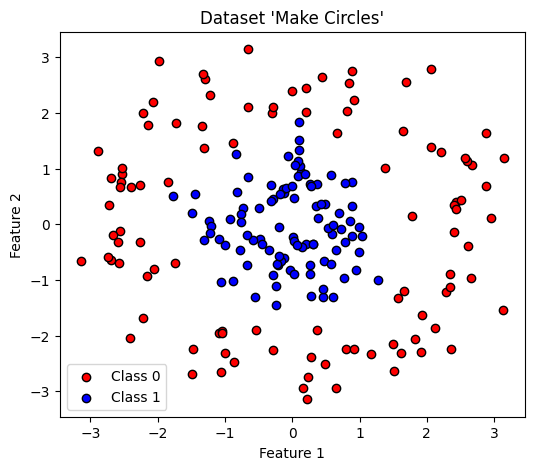

In [89]:
# Data Preparation
X, y = make_circles(n_samples=250, noise=0.15, factor=0.3, random_state=42)

# Scale features to [-π, π] for quantum angle encoding
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Visualizing
plt.figure(figsize=(6, 5))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], color='red', edgecolors='k', label="Class 0")
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], color='blue', edgecolors='k', label="Class 1")
plt.title("Dataset 'Make Circles'")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# Classical Models

In [90]:
# Classical Support Vector Machine
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, pred_linear)

In [91]:
# Classical Radial Basis Function SVM (Non-linear)
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, pred_rbf)

In [92]:
print("--- CLASSICAL MODELS PERFORMANCE ---")
print(f"Linear SVM Accuracy: {acc_linear * 100:.1f}%")
print(f"RBF SVM Accuracy:    {acc_rbf * 100:.1f}%")

--- CLASSICAL MODELS PERFORMANCE ---
Linear SVM Accuracy: 46.0%
RBF SVM Accuracy:    98.0%


# Quantum Models

In [93]:
# Quantum Kernel Circuit
n_qubits = 2
dev_kernel = qml.device("default.qubit", wires=n_qubits)

# Feature Map
def feature_map(x):
    qml.AngleEmbedding(x, wires=range(n_qubits))

@qml.qnode(dev_kernel)
def quantum_kernel_circuit(x1, x2):
    # Encode 1st data point
    feature_map(x1)
    # Inverse of the encoding for the 2nd data point
    qml.adjoint(feature_map)(x2)
    
    # Measure the probability of returning to the initial state |00>
    return qml.probs(wires=range(n_qubits))

# The kernel function returns the probability of the |00> state
def quantum_kernel_eval(x1, x2):
    return quantum_kernel_circuit(x1, x2)[0]

def calculate_gram_matrix(A, B):
    """
    Calculates the NxM Gram matrix using the quantum kernel.
    A and B are datasets (e.g., X_train and X_train).
    """
    matrix = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            matrix[i, j] = quantum_kernel_eval(A[i], B[j])
            
        # Optional: Print progress for large datasets
        if (i + 1) % 50 == 0:
            print(f"Computed {i + 1}/{len(A)} rows...")
            
    return matrix

In [94]:
# Gram matrix for training 
K_train = calculate_gram_matrix(X_train, X_train)

# Gram matrix for testing 
K_test = calculate_gram_matrix(X_test, X_train)

Computed 50/200 rows...
Computed 100/200 rows...
Computed 150/200 rows...
Computed 200/200 rows...
Computed 50/50 rows...


In [95]:
# Training
svm_quantum = SVC(kernel='precomputed') # Standard SVM with Quantum Kernel Matrix
svm_quantum.fit(K_train, y_train)

pred_quantum = svm_quantum.predict(K_test)
acc_quantum = accuracy_score(y_test, pred_quantum)

print(f"\nQuantum SVM Accuracy: {acc_quantum * 100:.1f}%")


Quantum SVM Accuracy: 98.0%


In [96]:
# Plot Decission Boundaries
def plot_qsvm_boundaries(svm_linear, svm_rbf, svm_quantum, X, y):
    h = 0.15  # Step size
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # Predict with Classical Models
    Z_linear = svm_linear.predict(grid).reshape(xx.shape)
    Z_rbf = svm_rbf.predict(grid).reshape(xx.shape)
    
    # Predict with Quantum Model
    K_grid = calculate_gram_matrix(grid, X_train)
    Z_quantum = svm_quantum.predict(K_grid).reshape(xx.shape)
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    titles = ['Linear SVM (Classical)', 'RBF SVM (Classical)', 'Quantum SVM']
    Z_list = [Z_linear, Z_rbf, Z_quantum]
    
    for ax, Z, title in zip(axes, Z_list, titles):
        ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.5)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        
    plt.tight_layout()
    plt.show()

Computed 50/2401 rows...
Computed 100/2401 rows...
Computed 150/2401 rows...
Computed 200/2401 rows...
Computed 250/2401 rows...
Computed 300/2401 rows...
Computed 350/2401 rows...
Computed 400/2401 rows...
Computed 450/2401 rows...
Computed 500/2401 rows...
Computed 550/2401 rows...
Computed 600/2401 rows...
Computed 650/2401 rows...
Computed 700/2401 rows...
Computed 750/2401 rows...
Computed 800/2401 rows...
Computed 850/2401 rows...
Computed 900/2401 rows...
Computed 950/2401 rows...
Computed 1000/2401 rows...
Computed 1050/2401 rows...
Computed 1100/2401 rows...
Computed 1150/2401 rows...
Computed 1200/2401 rows...
Computed 1250/2401 rows...
Computed 1300/2401 rows...
Computed 1350/2401 rows...
Computed 1400/2401 rows...
Computed 1450/2401 rows...
Computed 1500/2401 rows...
Computed 1550/2401 rows...
Computed 1600/2401 rows...
Computed 1650/2401 rows...
Computed 1700/2401 rows...
Computed 1750/2401 rows...
Computed 1800/2401 rows...
Computed 1850/2401 rows...
Computed 1900/2401 ro

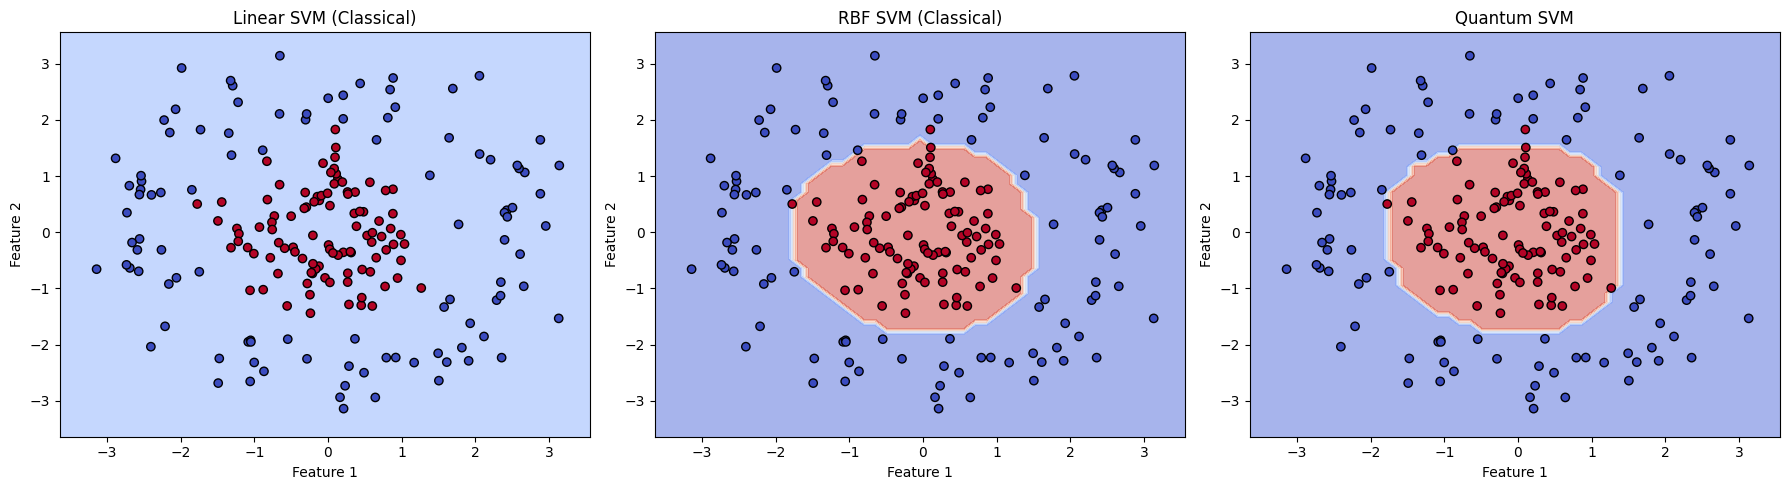

In [97]:
plot_qsvm_boundaries(svm_linear, svm_rbf, svm_quantum, X_train, y_train)

As we can see, it is impossible to separate linearly the 2 classes, but with kernels it is not a big deal.

In this case, RBF SVM and QSVM perform equally, because they only need to proyect 2 dimensions.

With Kernels we can avoid completely the Barren Plateaus that QNNs suffer, as Kernels don't use gradients.

But computationally evaluating a Gram matrix escales cuadratically with the data, it spends a lot of time with big data.

However, Quantum Kernels proyect the data in a Hilbert Space of 2^n dimensions, so it is easy to find a hyperplane that separates data with very complex relations.

# Label Noise to the data

We will add noise on purpose to the dataset at training, flipping some samples and then evaluating in the non-noisy dataset. 

Therefore, we will see how robust our models are and if they ignore noise.

Flipped 60 labels out of 200 training points.


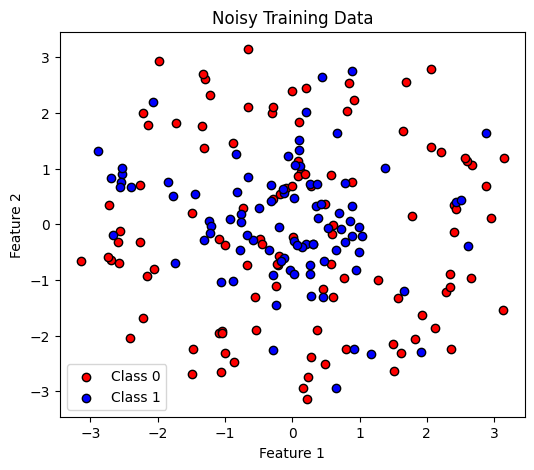

In [113]:
# Label noise
noise_level = 0.3


n_samples = len(y_train)
n_flips = int(noise_level * n_samples)

# Flip random indexes
np.random.seed(67) 
flip_indices = np.random.choice(n_samples, n_flips, replace=False)


y_train_noisy = y_train.copy()
y_train_noisy[flip_indices] = 1 - y_train_noisy[flip_indices] # Flip Labels

print(f"Flipped {n_flips} labels out of {n_samples} training points.")

# Visualize
plt.figure(figsize=(6, 5))
plt.scatter(X_train[y_train_noisy==0, 0], X_train[y_train_noisy==0, 1], color='red', edgecolors='k', label="Class 0")
plt.scatter(X_train[y_train_noisy==1, 0], X_train[y_train_noisy==1, 1], color='blue', edgecolors='k', label="Class 1")
plt.title("Noisy Training Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# Classical models with noisy data

In [114]:
# Linear SVM
svm_linear_noisy = SVC(kernel='linear')
svm_linear_noisy.fit(X_train, y_train_noisy)
pred_linear_noisy = svm_linear_noisy.predict(X_test) 
acc_linear_noisy = accuracy_score(y_test, pred_linear_noisy) # evaluate on clean

In [115]:
# RBF SVM
svm_rbf_noisy = SVC(kernel='rbf')
svm_rbf_noisy.fit(X_train, y_train_noisy)
pred_rbf_noisy = svm_rbf_noisy.predict(X_test)
acc_rbf_noisy = accuracy_score(y_test, pred_rbf_noisy) # evaluate on clean

In [116]:
svm_quantum_noisy = SVC(kernel='precomputed')
svm_quantum_noisy.fit(K_train, y_train_noisy) # Reuse K_train (the Kernel Matrix) as is the same matrix
pred_quantum_noisy = svm_quantum_noisy.predict(K_test)
acc_quantum_noisy = accuracy_score(y_test, pred_quantum_noisy)

In [117]:
print("--- PERFORMANCE ON CLEAN TEST SET (TRAINED ON NOISY DATA) ---")
print(f"Linear SVM Accuracy:  {acc_linear_noisy * 100:.1f}%")
print(f"RBF SVM Accuracy:     {acc_rbf_noisy * 100:.1f}%")
print(f"Quantum SVM Accuracy: {acc_quantum_noisy * 100:.1f}%")

--- PERFORMANCE ON CLEAN TEST SET (TRAINED ON NOISY DATA) ---
Linear SVM Accuracy:  46.0%
RBF SVM Accuracy:     92.0%
Quantum SVM Accuracy: 98.0%


Computed 50/2401 rows...
Computed 100/2401 rows...
Computed 150/2401 rows...
Computed 200/2401 rows...
Computed 250/2401 rows...
Computed 300/2401 rows...
Computed 350/2401 rows...
Computed 400/2401 rows...
Computed 450/2401 rows...
Computed 500/2401 rows...
Computed 550/2401 rows...
Computed 600/2401 rows...
Computed 650/2401 rows...
Computed 700/2401 rows...
Computed 750/2401 rows...
Computed 800/2401 rows...
Computed 850/2401 rows...
Computed 900/2401 rows...
Computed 950/2401 rows...
Computed 1000/2401 rows...
Computed 1050/2401 rows...
Computed 1100/2401 rows...
Computed 1150/2401 rows...
Computed 1200/2401 rows...
Computed 1250/2401 rows...
Computed 1300/2401 rows...
Computed 1350/2401 rows...
Computed 1400/2401 rows...
Computed 1450/2401 rows...
Computed 1500/2401 rows...
Computed 1550/2401 rows...
Computed 1600/2401 rows...
Computed 1650/2401 rows...
Computed 1700/2401 rows...
Computed 1750/2401 rows...
Computed 1800/2401 rows...
Computed 1850/2401 rows...
Computed 1900/2401 ro

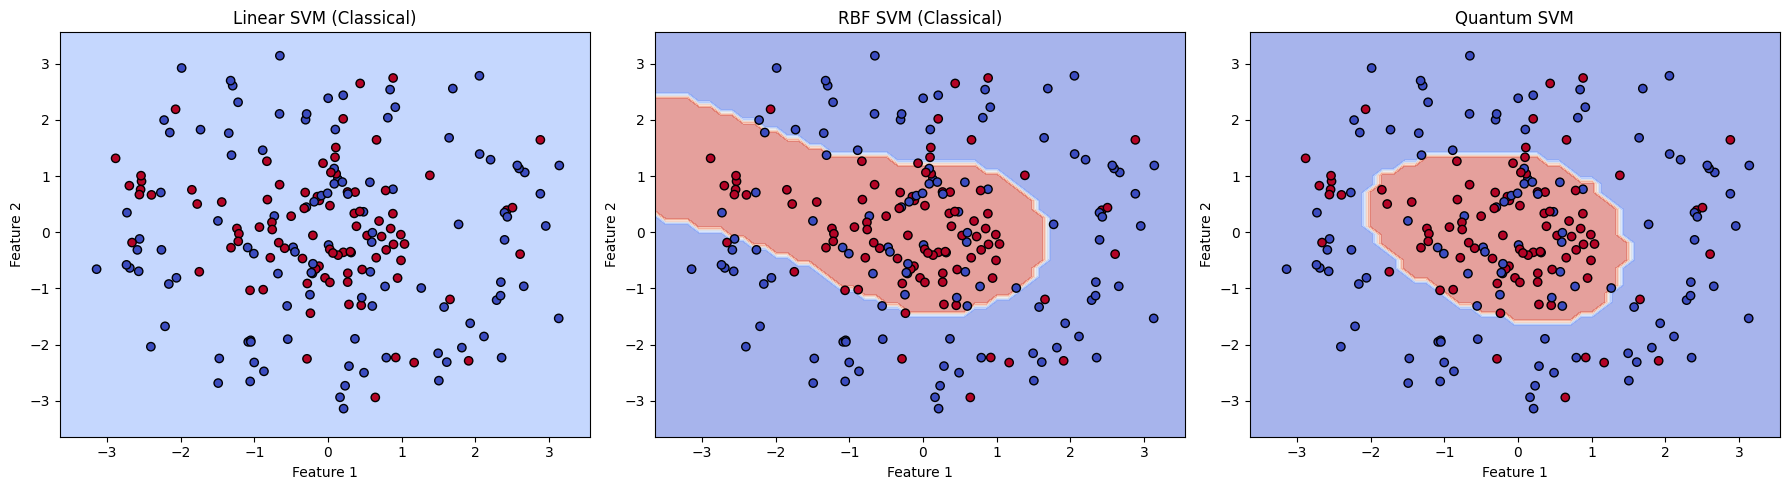

In [118]:
plot_qsvm_boundaries(svm_linear_noisy, svm_rbf_noisy, svm_quantum_noisy, X_train, y_train_noisy)

Here we can see that with noisy data, it is easier to classical models to fall in some outliers while quantum models tend to be more robust